<a href="https://colab.research.google.com/github/takeonakamura6-design/so/blob/main/Swapping%20e%20MVirtual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Swapping vs Memória Virtual

--- RESULTADOS DA SIMULAÇÃO (PAGINAÇÕES/FALHAS) ---
 Quadros  FIFO  LRU  MRU
       2    45   45   35
       3    34   26   32
       4    29   24   31
       5    14   11   21
       6     9    8   21
       7     8    8   14


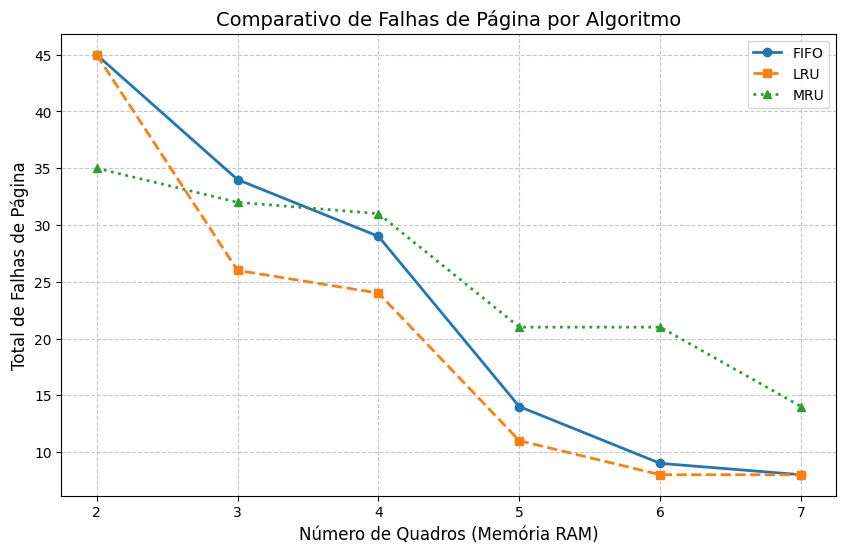


[INFO] Gráfico salvo com sucesso como 'grafico.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def simular_fifo(referencias, quadros):
    memoria = []
    falhas = 0
    for pagina in referencias:
        if pagina not in memoria:
            if len(memoria) < quadros:
                memoria.append(pagina)
            else:
                memoria.pop(0)
                memoria.append(pagina)
            falhas += 1
    return falhas

def simular_lru(referencias, quadros):
    memoria = []
    falhas = 0
    for pagina in referencias:
        if pagina not in memoria:
            if len(memoria) < quadros:
                memoria.append(pagina)
            else:
                memoria.pop(0)
                memoria.append(pagina)
            falhas += 1
        else:
            # Move para o final para marcar como usado recentemente
            memoria.remove(pagina)
            memoria.append(pagina)
    return falhas

def simular_mru(referencias, quadros):
    memoria = []
    falhas = 0
    for pagina in referencias:
        if pagina not in memoria:
            if len(memoria) < quadros:
                memoria.append(pagina)
            else:
                # Remove o mais recentemente usado (o último da lista)
                memoria.pop()
                memoria.append(pagina)
            falhas += 1
        else:
            # Atualiza a posição do elemento usado
            memoria.remove(pagina)
            memoria.append(pagina)
    return falhas

def executar_experimento():
    # Configuração do Experimento
    np.random.seed(42)
    # Gera string de referência com localidade temporal
    refs = [np.random.randint(0, 10) for _ in range(20)] + [1, 2, 3, 1, 2, 4, 1, 2, 5] * 3
    intervalo_quadros = range(2, 8)

    resultados = []

    for q in intervalo_quadros:
        f_fifo = simular_fifo(refs, q)
        f_lru = simular_lru(refs, q)
        f_mru = simular_mru(refs, q)
        resultados.append({"Quadros": q, "FIFO": f_fifo, "LRU": f_lru, "MRU": f_mru})

    # 1. Geração da Tabela de Dados
    df = pd.DataFrame(resultados)
    print("--- RESULTADOS DA SIMULAÇÃO (PAGINAÇÕES/FALHAS) ---")
    print(df.to_string(index=False))

    # 2. Geração do Gráfico Científico
    plt.figure(figsize=(10, 6))
    plt.plot(df["Quadros"], df["FIFO"], marker='o', linestyle='-', label='FIFO', linewidth=2)
    plt.plot(df["Quadros"], df["LRU"], marker='s', linestyle='--', label='LRU', linewidth=2)
    plt.plot(df["Quadros"], df["MRU"], marker='^', linestyle=':', label='MRU', linewidth=2)

    plt.title('Comparativo de Falhas de Página por Algoritmo', fontsize=14)
    plt.xlabel('Número de Quadros (Memória RAM)', fontsize=12)
    plt.ylabel('Total de Falhas de Página', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Salvar para anexo no Zenodo
    plt.savefig('grafico.png', dpi=300)
    plt.show()
    print("\n[INFO] Gráfico salvo com sucesso como 'grafico.png'")

if __name__ == "__main__":
    executar_experimento()